# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree


## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

## Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.

In [2]:
df = pd.read_csv('../../data/am_pm.csv')
df[['target', 'predict']] = df[['target', 'predict']].replace(
    {'working_day': 1, 'weekend': 0}
)

/tmp/ipykernel_28031/2986022981.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['target', 'predict']] = df[['target', 'predict']].replace(


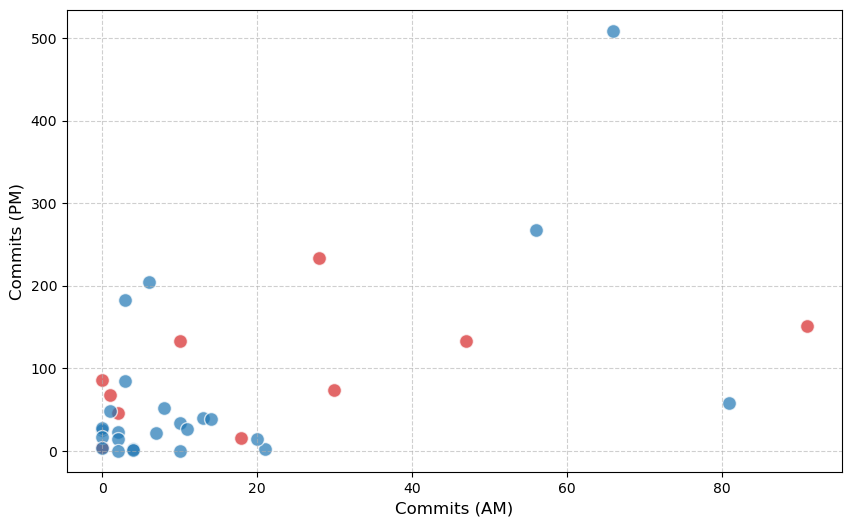

In [3]:
def show_graph(df, col, x_plot=None, y_plot=None):
    plt.figure(figsize=(10, 6))

    colors = {1: 'tab:blue', 0: 'tab:red'}

    for target_type, group in df.groupby(col):
        plt.scatter(
            group['am'], 
            group['pm'], 
            label=target_type, 
            color=colors[target_type],
            alpha=0.7, 
            edgecolors='w', 
            s=100  
        )

    plt.xlabel('Commits (AM)', fontsize=12)
    plt.ylabel('Commits (PM)', fontsize=12)
    # plt.legend(title='Day Type')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if x_plot is not None and y_plot is not None:
        plt.plot(x_plot, y_plot, color='green')
    plt.show()
show_graph(df,'target')

## Add the decision boundary of logistic regression to the plot.

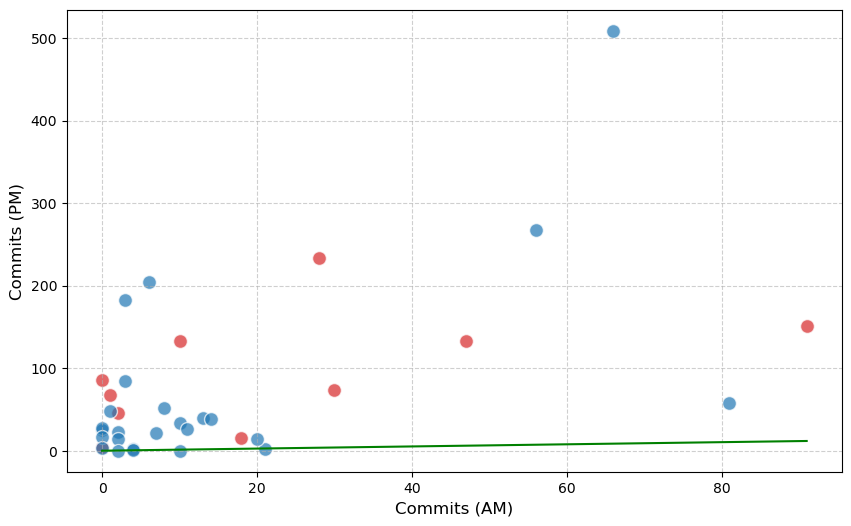

In [4]:

X = df[['am', 'pm']]
y = df['target']

lr = LogisticRegression(random_state=21, fit_intercept=False)
lr.fit(X, y)

x_min, x_max = df['am'].min(), df['am'].max()
target_plot = np.linspace(x_min, x_max)

w = lr.coef_[0]
# x2_values = -(w1 * x1_values) / w2
decision_bound = -(w[0] * target_plot) / w[1]


show_graph(df,'target',target_plot,decision_bound)

## Draw the same plot (with the boundary), but the color should depend this time on the predictions.

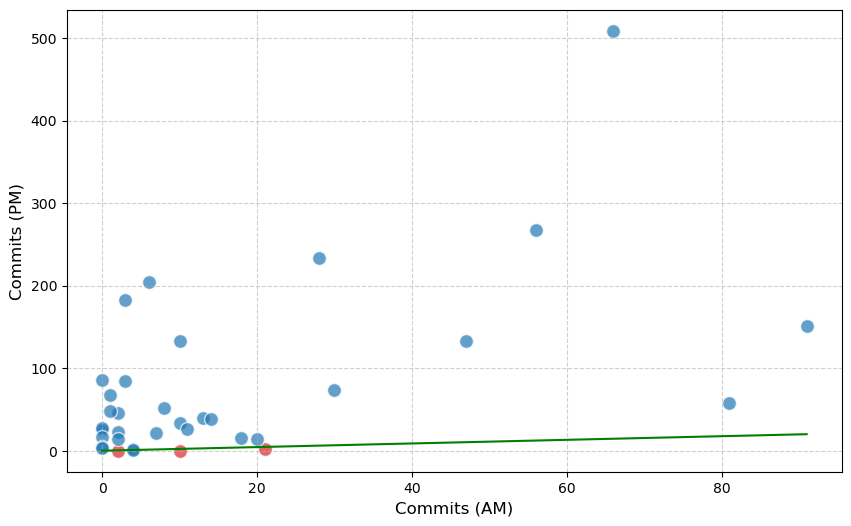

In [5]:

X = df[['am', 'pm']]
y = df['predict']

lr = LogisticRegression(random_state=21, fit_intercept=False)
lr.fit(X, y)

x_min, x_max = df['am'].min(), df['am'].max()
x_plot = np.linspace(x_min, x_max)

w = lr.coef_[0]
# x2_values = -(w1 * x1_values) / w2
y_plot = -(w[0] * x_plot) / w[1]

show_graph(df,'predict',x_plot,y_plot)


## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [6]:
X = df[['am', 'pm']]

standardizer = StandardScaler()
standardizer = standardizer.fit(X)

x_scaled = pd.DataFrame(
    standardizer.transform(X),
    index=X.index,
    columns=X.columns
)

lr_scaled = LogisticRegression(fit_intercept=False, random_state=21)
lr_scaled.fit(x_scaled, df["target"])

predict_scaled = lr_scaled.predict(x_scaled)


In [7]:
accuracy_score(df['target'], predict_scaled)

0.7428571428571429

In [8]:
accuracy_score(df['target'], [df['target'].mode()[0]] * len(df['target']))

0.7142857142857143

The accuracy has got better.

## Draw plots

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


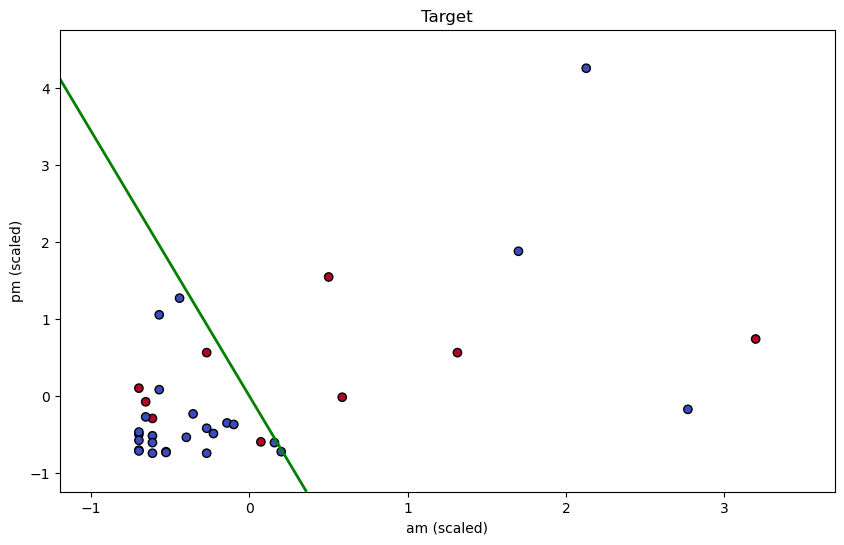

In [9]:
# all possible options
x_array, y_array = np.meshgrid(np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
                     np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500))


# 1D arrays
Z = lr_scaled.predict_proba(np.c_[x_array.ravel(), y_array.ravel()])[:, 1]
# matrix 
Z = Z.reshape(x_array.shape)

    
plt.figure(figsize=(10, 6))
plt.scatter(x_scaled['am'], x_scaled['pm'], 
            c=df['target'], cmap='coolwarm_r', edgecolors='black')

plt.contour(x_array, y_array, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('Target')
plt.show()

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


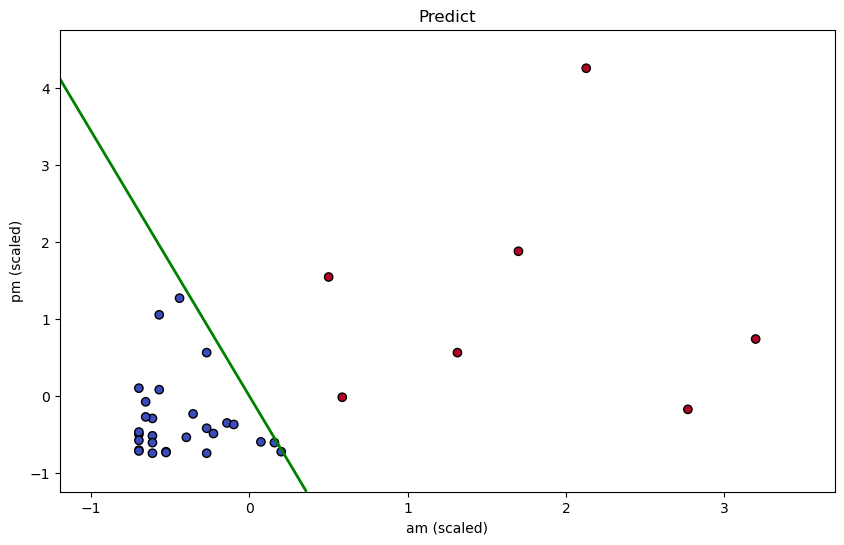

In [10]:
# all possible options
x_array, y_array = np.meshgrid(np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
                     np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500))


# 1D arrays
Z = lr_scaled.predict_proba(np.c_[x_array.ravel(), y_array.ravel()])[:, 1]
# matrix 
Z = Z.reshape(x_array.shape)

    
plt.figure(figsize=(10, 6))
plt.scatter(x_scaled['am'], x_scaled['pm'], 
            c=predict_scaled, cmap='coolwarm_r', edgecolors='black')

plt.contour(x_array, y_array, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('Predict')
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

## Default SVC (rbf kernel)

In [11]:
svc_best = SVC(probability=True, random_state=21)
svc_best.fit(x_scaled, df['target'])
svc_best_predict = svc_best.predict(x_scaled)
accuracy_score(df['target'],svc_best_predict)

0.7428571428571429

## Different Kernels

In [12]:
svc = SVC(probability=True, random_state=21, kernel='linear')
svc.fit(x_scaled, df['target'])
svc_predict = svc.predict(x_scaled)
accuracy_score(df['target'],svc_predict)

0.7142857142857143

In [13]:
svc = SVC(probability=True, random_state=21, kernel='poly')
svc.fit(x_scaled, df['target'])
svc_predict = svc.predict(x_scaled)
accuracy_score(df['target'],svc_predict)

0.7428571428571429

In [14]:
svc = SVC(probability=True, random_state=21, kernel='sigmoid')
svc.fit(x_scaled, df['target'])
svc_predict = svc.predict(x_scaled)
accuracy_score(df['target'],svc_predict)

0.6857142857142857

The best ones are poly and rbf (default).

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


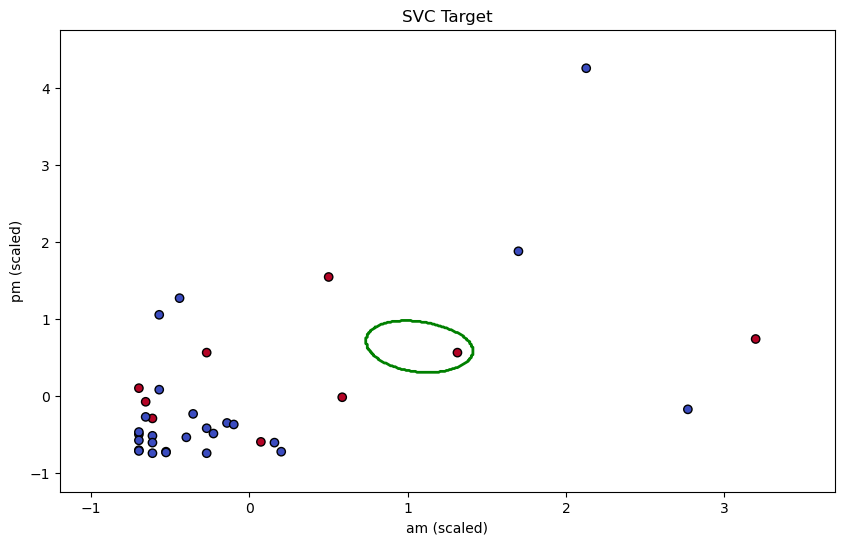

In [15]:

x_array, y_array = np.meshgrid(
    np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
    np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500)
)

grid_points = np.c_[x_array.ravel(), y_array.ravel()]
Z = svc_best.predict_proba(grid_points)[:, 1]  

Z = Z.reshape(x_array.shape)

plt.figure(figsize=(10, 6))

plt.scatter(
    x_scaled['am'], x_scaled['pm'],
    c=df['target'], cmap='coolwarm_r', edgecolors='black'
)

plt.contour(x_array, y_array, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('SVC Target')
plt.show()

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


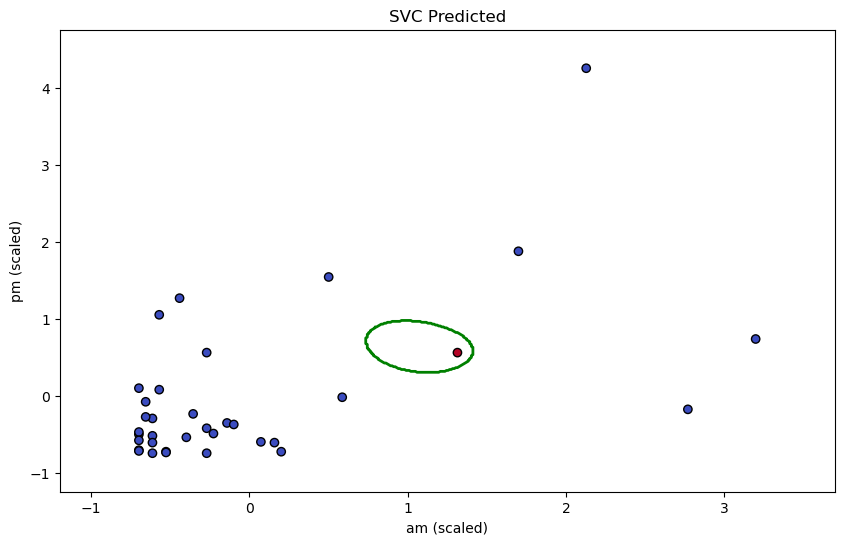

In [16]:

x_array, y_array = np.meshgrid(
    np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
    np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500)
)

grid_points = np.c_[x_array.ravel(), y_array.ravel()]
Z = svc_best.predict_proba(grid_points)[:, 1]  

Z = Z.reshape(x_array.shape)

plt.figure(figsize=(10, 6))

plt.scatter(
    x_scaled['am'], x_scaled['pm'],
    c=svc_best_predict, cmap='coolwarm_r', edgecolors='black'
)

plt.contour(x_array, y_array, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('SVC Predicted')
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [17]:
tree_four = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_four.fit(x_scaled,df['target'])
tree_four_predict = tree_four.predict(x_scaled)
accuracy_score(df['target'],tree_four_predict)

0.9428571428571428

In [18]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(x_scaled,df['target'])
tree_predict = tree.predict(x_scaled)
accuracy_score(df['target'],tree_predict)

0.8571428571428571

In [19]:
tree = DecisionTreeClassifier(max_depth=8, random_state=42)
tree.fit(x_scaled,df['target'])
tree_predict = tree.predict(x_scaled)
accuracy_score(df['target'],tree_predict)

1.0

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


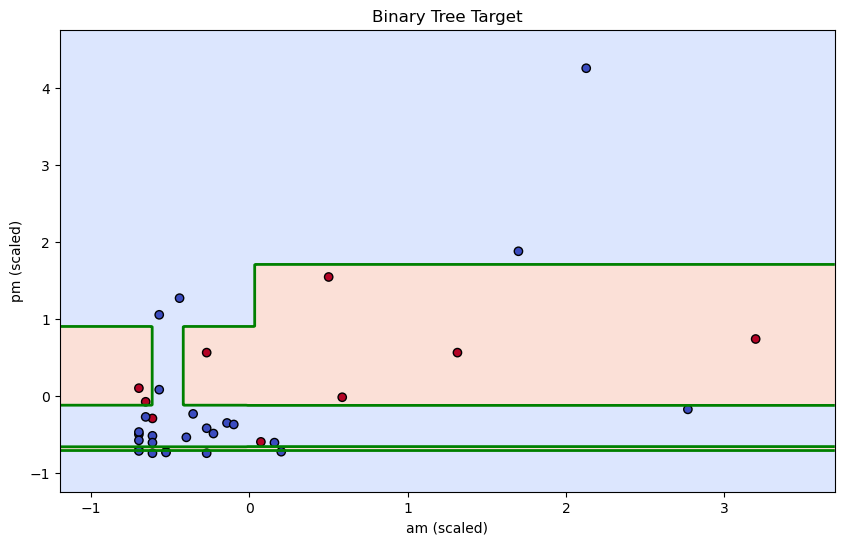

In [20]:
x_array, y_array = np.meshgrid(
    np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
    np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500)
)

grid_points = np.c_[x_array.ravel(), y_array.ravel()]
Z = tree_four.predict_proba(grid_points)[:, 1]  

Z = Z.reshape(x_array.shape)

plt.figure(figsize=(10, 6))

plt.contourf(
    x_array, y_array, Z, 
    levels=[0, 0.5, 1],     
    alpha=0.3,              
    cmap='coolwarm_r'
)

plt.scatter(
    x_scaled['am'], x_scaled['pm'],
    c=df['target'], cmap='coolwarm_r', edgecolors='black'
)

plt.contour(
    x_array, y_array, Z,
    levels=[0.5],
    colors='green', linewidths=2
)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('Binary Tree Target')
plt.show()

/home/elijah/miniconda3/envs/ds_env_1/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


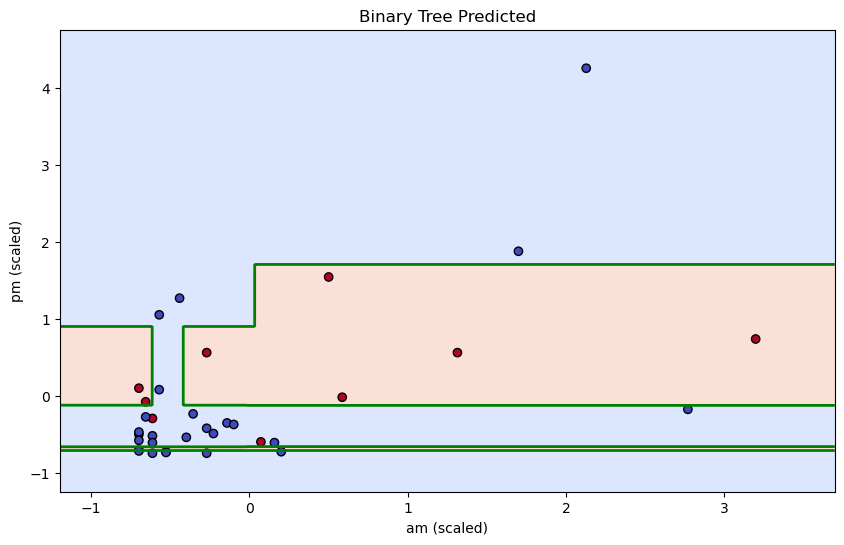

In [21]:
x_array, y_array = np.meshgrid(
    np.linspace(x_scaled['am'].min() - 0.5, x_scaled['am'].max() + 0.5, 500),
    np.linspace(x_scaled['pm'].min() - 0.5, x_scaled['pm'].max() + 0.5, 500)
)

grid_points = np.c_[x_array.ravel(), y_array.ravel()]
Z = tree_four.predict_proba(grid_points)[:, 1]  

Z = Z.reshape(x_array.shape)

plt.figure(figsize=(10, 6))

plt.contourf(
    x_array, y_array, Z, 
    levels=[0, 0.5, 1],     
    alpha=0.3,              
    cmap='coolwarm_r'
)

plt.scatter(
    x_scaled['am'], x_scaled['pm'],
    c=tree_predict, cmap='coolwarm_r', edgecolors='black'
)

plt.contour(
    x_array, y_array, Z,
    levels=[0.5],
    colors='green', linewidths=2
)

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.title('Binary Tree Predicted')
plt.show()

## Visualization of the tree

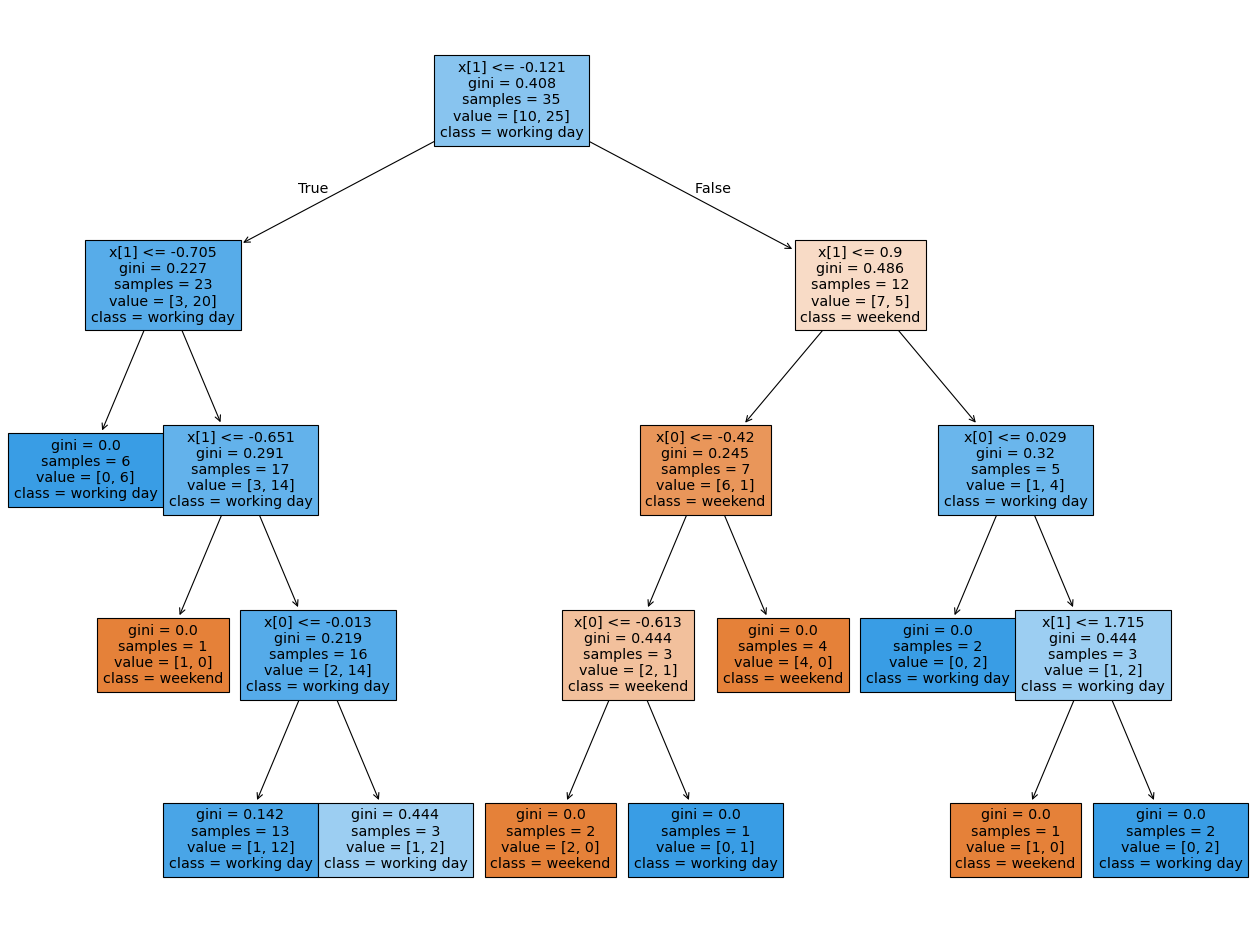

In [22]:
plt.style.use('default')
plt.figure(figsize=(20,15), dpi=80)
plot_tree(tree_four,
          class_names=['weekend','working day'],
          filled=True)
plt.show()

## How many leaves in the visualized tree label days as working days? 6